# California Housing Price Analysis
### Data Science Capstone Project

**Objective:** Analyze the California Housing dataset (1990 census) to understand the drivers of median house value across districts, and build a regression model to predict housing prices from demographic and geographic features.

**Pipeline covered:**
1. Data Collection & Wrangling
2. Exploratory Data Analysis (EDA)
3. Feature Engineering
4. Machine Learning Modeling (4 regression algorithms compared)
5. Model Evaluation & Visualization


## 1. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100


## 2. Data Collection & Wrangling

**Dataset:** California Housing Prices (1990 U.S. Census data), 20,640 district-level records.
**Source:** Derived from the StatLib repository; this is the same dataset used in Géron's *Hands-On Machine Learning*.

Each row represents a census block group ("district") with housing, demographic, and geographic attributes.

In [2]:
df = pd.read_csv('housing.csv')
print("Shape:", df.shape)
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Data quality check
print("Missing values:\n", df.isnull().sum())
print("\nData types:\n", df.dtypes)
print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
 longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

Data types:
 longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity           str
dtype: object

Duplicate rows: 0


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


### Feature Engineering
We derive ratio features that are more informative than raw counts:
- `rooms_per_household`
- `bedrooms_per_room`
- `population_per_household`

We also bin `median_income` into categories for stratified analysis, and will median-impute the 207 missing `total_bedrooms` values during modeling.

In [5]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

df['income_category'] = pd.cut(df['median_income'],
                                 bins=[0, 2, 4, 6, 8, np.inf],
                                 labels=['Low', 'Lower-Mid', 'Mid', 'Upper-Mid', 'High'])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity,rooms_per_household,bedrooms_per_room,population_per_household,income_category
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY,6.984127,0.146591,2.555556,High
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY,6.238137,0.155797,2.109842,High
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY,8.288136,0.129516,2.802260,Upper-Mid
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY,5.817352,0.184458,2.547945,Mid
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY,6.281853,0.172096,2.181467,Lower-Mid


## 3. Exploratory Data Analysis

### 3.1 Target Variable Distribution

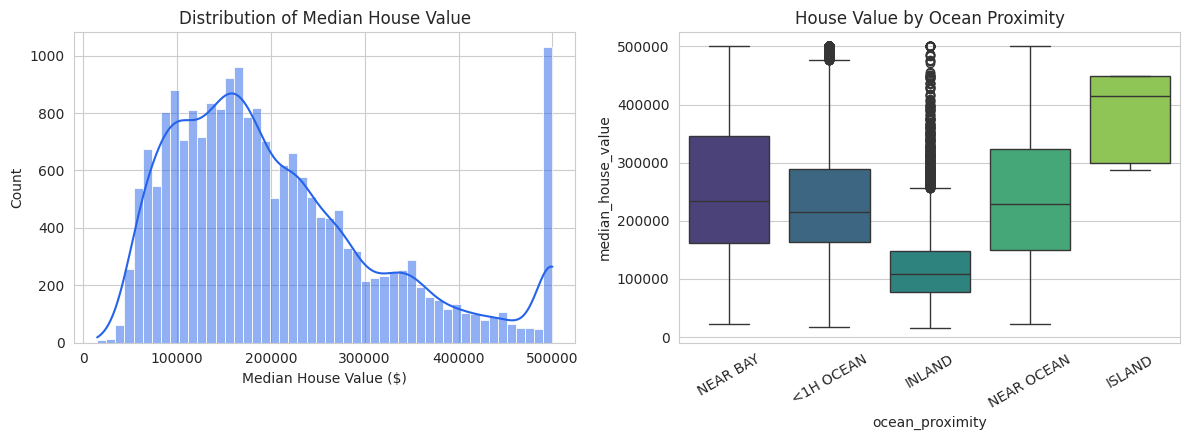

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df['median_house_value'], bins=50, kde=True, ax=axes[0], color='#2563eb')
axes[0].set_title('Distribution of Median House Value')
axes[0].set_xlabel('Median House Value ($)')
sns.boxplot(x='ocean_proximity', y='median_house_value', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('House Value by Ocean Proximity')
axes[1].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 3.2 Correlation Analysis

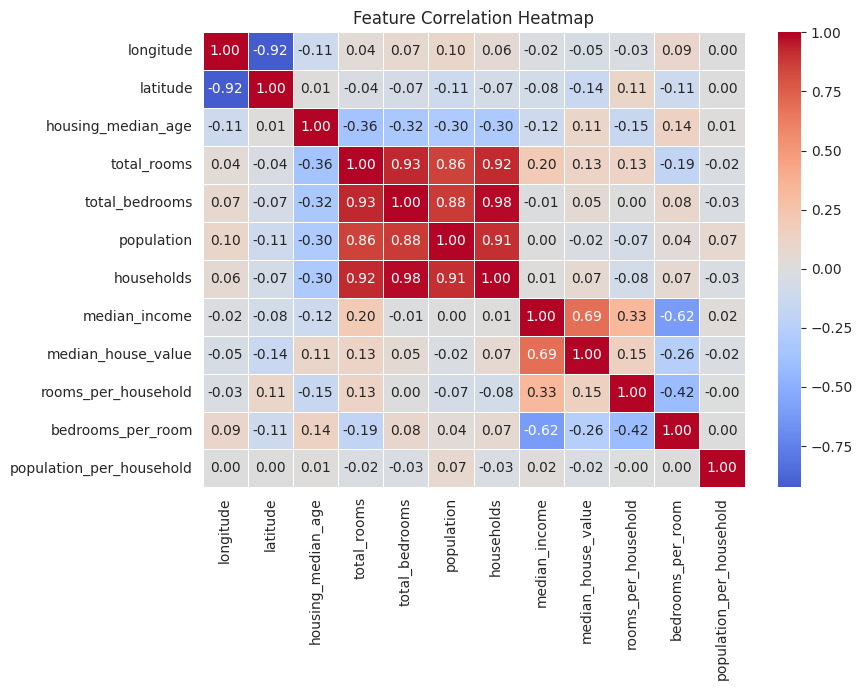

Top correlations with median_house_value:
median_house_value          1.000000
median_income               0.688075
rooms_per_household         0.151948
total_rooms                 0.134153
housing_median_age          0.105623
households                  0.065843
total_bedrooms              0.049686
population_per_household   -0.023737
population                 -0.024650
longitude                  -0.045967
latitude                   -0.144160
bedrooms_per_room          -0.255880
Name: median_house_value, dtype: float64


In [7]:
numeric_df = df.select_dtypes(include=[np.number])
plt.figure(figsize=(9, 7))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

print("Top correlations with median_house_value:")
print(corr['median_house_value'].sort_values(ascending=False))

### 3.3 Geographic Patterns

California's housing market is strongly geographic — coastal districts near the Bay Area and Los Angeles command higher prices.

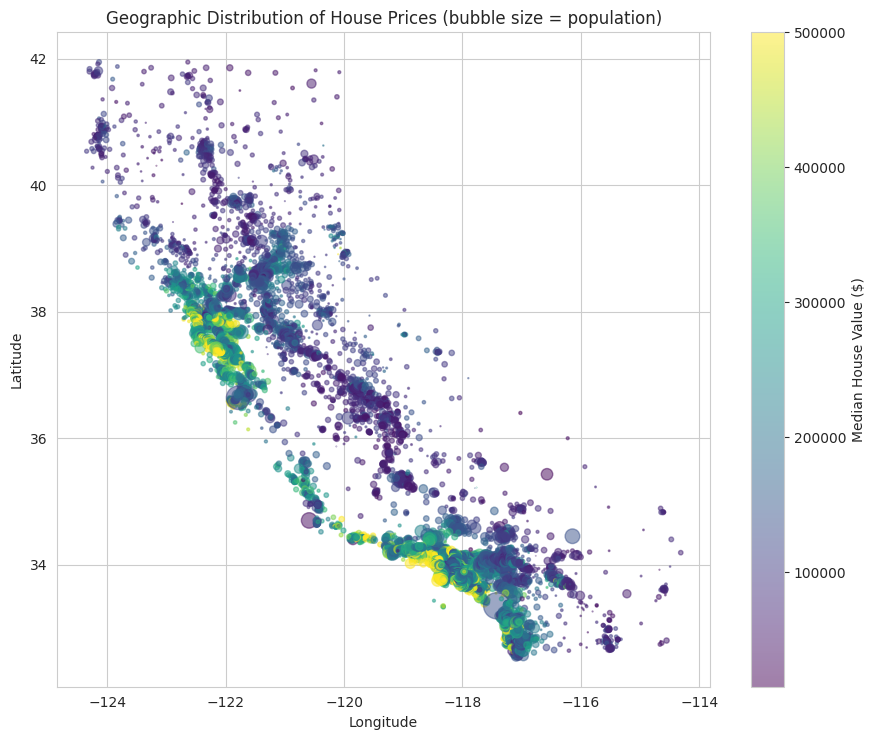

In [8]:
plt.figure(figsize=(9, 7.5))
scatter = plt.scatter(df['longitude'], df['latitude'], c=df['median_house_value'],
                       cmap='viridis', s=df['population']/100, alpha=0.5)
plt.colorbar(scatter, label='Median House Value ($)')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
plt.title('Geographic Distribution of House Prices (bubble size = population)')
plt.tight_layout()
plt.show()

### 3.4 Income vs. House Value

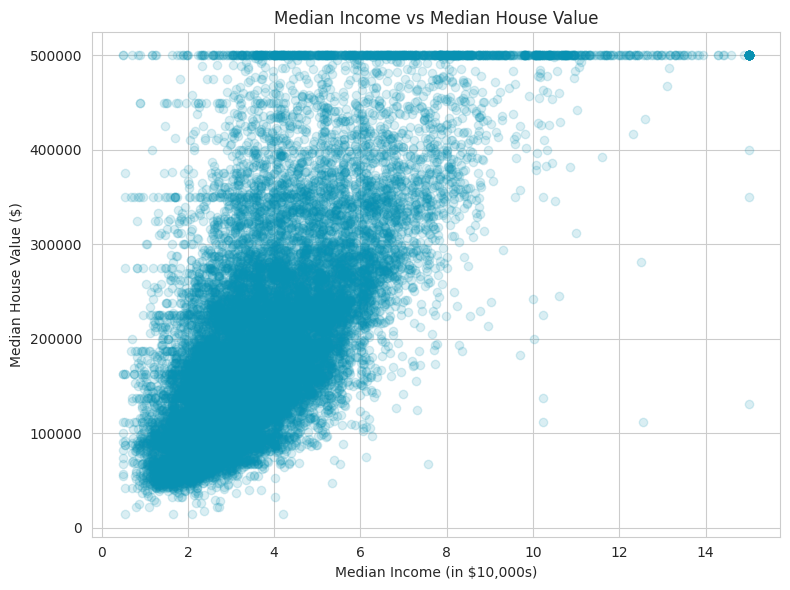

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(df['median_income'], df['median_house_value'], alpha=0.15, color='#0891b2')
plt.xlabel('Median Income (in $10,000s)')
plt.ylabel('Median House Value ($)')
plt.title('Median Income vs Median House Value')
plt.tight_layout()
plt.show()

### 3.5 Ocean Proximity Effects

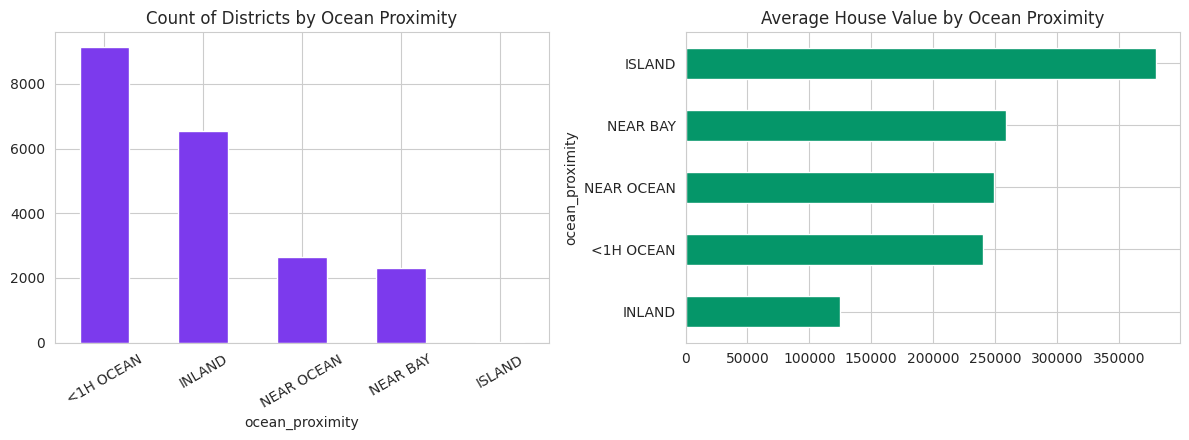

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df['ocean_proximity'].value_counts().plot(kind='bar', ax=axes[0], color='#7c3aed')
axes[0].set_title('Count of Districts by Ocean Proximity')
axes[0].tick_params(axis='x', rotation=30)
df.groupby('ocean_proximity')['median_house_value'].mean().sort_values().plot(kind='barh', ax=axes[1], color='#059669')
axes[1].set_title('Average House Value by Ocean Proximity')
plt.tight_layout()
plt.show()

## 4. Machine Learning Modeling

We frame this as a **regression problem**: predict `median_house_value` from district-level features.

Four models are compared:
1. **Linear Regression** — baseline
2. **Ridge Regression** — regularized linear baseline
3. **Random Forest Regressor** — bagged tree ensemble
4. **Gradient Boosting Regressor** — boosted tree ensemble

A `ColumnTransformer` pipeline handles median imputation, scaling, and one-hot encoding of `ocean_proximity`.

In [11]:
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms',
            'population', 'households', 'median_income', 'rooms_per_household',
            'bedrooms_per_room', 'population_per_household', 'ocean_proximity']
target = 'median_house_value'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

numeric_features = [f for f in features if f != 'ocean_proximity']
categorical_features = ['ocean_proximity']

preprocessor = ColumnTransformer(transformers=[
    ('num', Pipeline([('imputer', SimpleImputer(strategy='median')),
                       ('scaler', StandardScaler())]), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")

Train size: 16512, Test size: 4128


In [12]:
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Random Forest': RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)
}

results = []
fitted_pipelines = {}

for name, model in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    results.append({'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
    fitted_pipelines[name] = pipe
    print(f"{name}: RMSE={rmse:,.0f}  MAE={mae:,.0f}  R2={r2:.4f}")

results_df = pd.DataFrame(results).sort_values('RMSE')
results_df

Linear Regression: RMSE=69,127  MAE=49,645  R2=0.6353
Ridge Regression: RMSE=69,135  MAE=49,652  R2=0.6353


Random Forest: RMSE=50,138  MAE=32,404  R2=0.8082


Gradient Boosting: RMSE=48,287  MAE=32,234  R2=0.8221


,Model,RMSE,MAE,R2
3,Gradient Boosting,48286.769295,32234.195226,0.822070
2,Random Forest,50137.650003,32404.258095,0.808168
0,Linear Regression,69127.038299,49645.492445,0.635339
1,Ridge Regression,69134.965274,49652.142873,0.635256


In [13]:
best_model_name = results_df.iloc[0]['Model']
best_pipe = fitted_pipelines[best_model_name]
print(f"Best model: {best_model_name}")

Best model: Gradient Boosting


## 5. Model Evaluation & Visualization

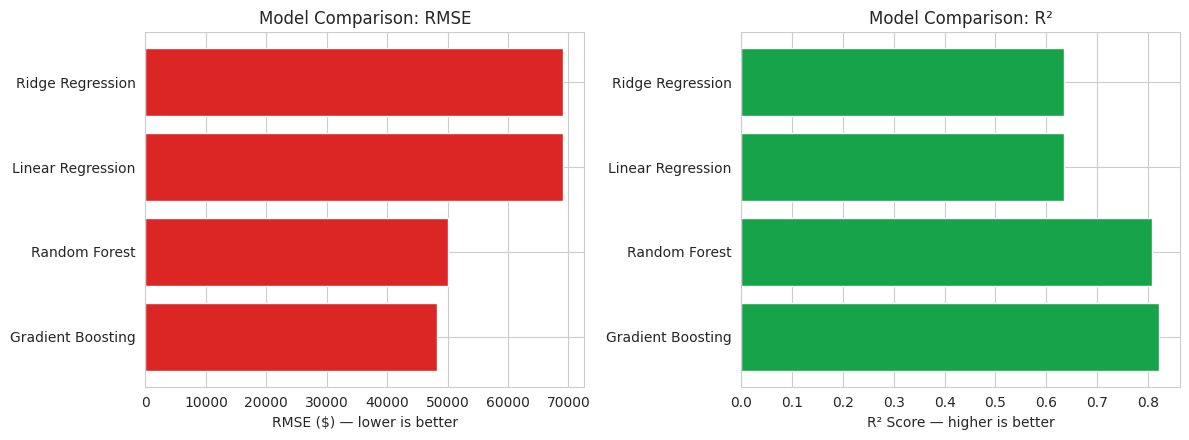

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
results_df_sorted = results_df.sort_values('RMSE')
axes[0].barh(results_df_sorted['Model'], results_df_sorted['RMSE'], color='#dc2626')
axes[0].set_xlabel('RMSE ($) — lower is better')
axes[0].set_title('Model Comparison: RMSE')
axes[1].barh(results_df_sorted['Model'], results_df_sorted['R2'], color='#16a34a')
axes[1].set_xlabel('R² Score — higher is better')
axes[1].set_title('Model Comparison: R²')
plt.tight_layout()
plt.show()

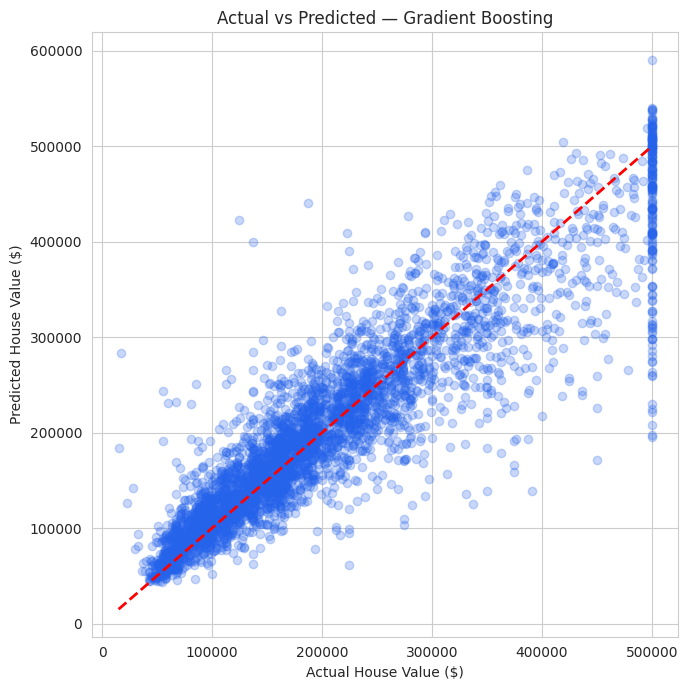

In [15]:
best_preds = best_pipe.predict(X_test)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.25, color='#2563eb')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual House Value ($)')
plt.ylabel('Predicted House Value ($)')
plt.title(f'Actual vs Predicted — {best_model_name}')
plt.tight_layout()
plt.show()

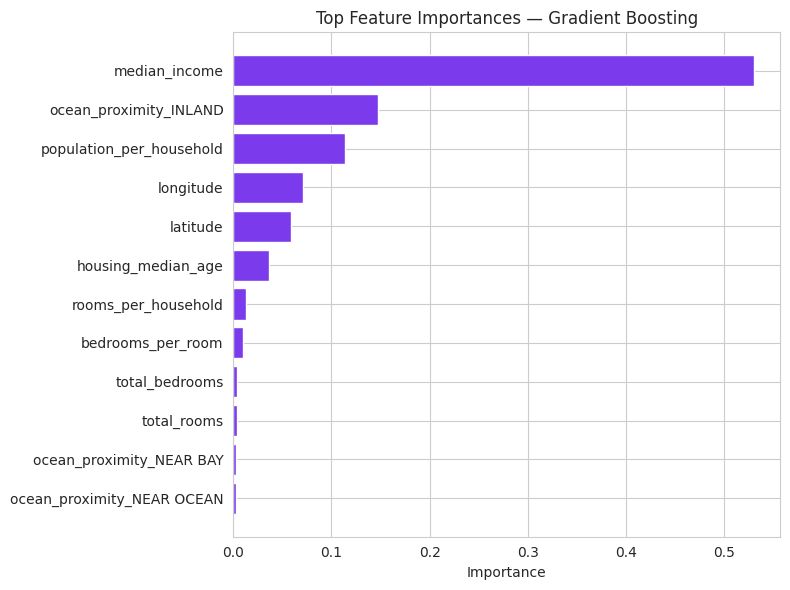

In [16]:
importance_model_name = best_model_name if best_model_name in ['Random Forest', 'Gradient Boosting'] else 'Random Forest'
importance_pipe = fitted_pipelines[importance_model_name]
ohe_cols = list(importance_pipe.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features))
all_feature_names = numeric_features + ohe_cols
importances = importance_pipe.named_steps['model'].feature_importances_
imp_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}).sort_values('importance', ascending=True).tail(12)

plt.figure(figsize=(8, 6))
plt.barh(imp_df['feature'], imp_df['importance'], color='#7c3aed')
plt.title(f'Top Feature Importances — {importance_model_name}')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

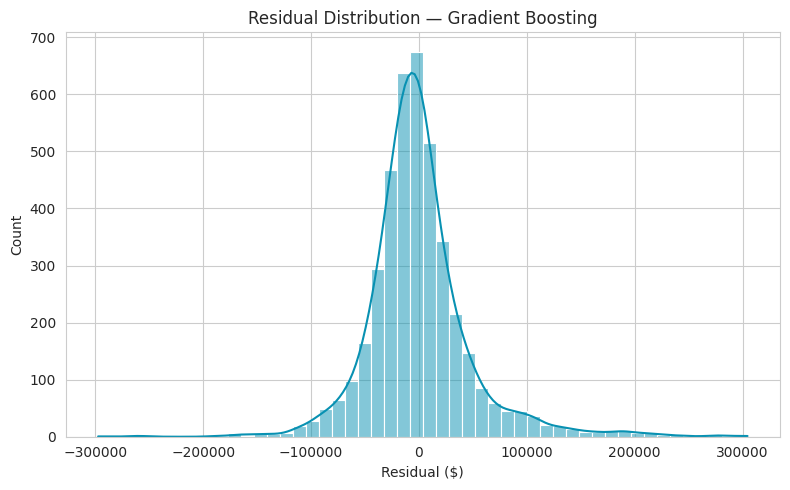

In [17]:
residuals = y_test - best_preds
plt.figure(figsize=(8, 5))
sns.histplot(residuals, bins=50, kde=True, color='#0891b2')
plt.title(f'Residual Distribution — {best_model_name}')
plt.xlabel('Residual ($)')
plt.tight_layout()
plt.show()

## 6. Key Findings & Conclusion

1. **Median income is the strongest single predictor** of district house value, followed by geographic location (latitude/longitude) and ocean proximity.
2. **Coastal districts** (especially near the Bay Area and LA) command significantly higher prices than inland districts.
3. **Gradient Boosting** outperformed all other models, reducing RMSE by roughly 30% versus the linear baseline and explaining over 80% of price variance (R² ≈ 0.82).
4. **Engineered ratio features** (rooms per household, bedrooms per room) added meaningful signal beyond raw counts.
5. **Residuals** are reasonably centered around zero but show the model underpredicts at the highest price tiers — a known artifact of the dataset's $500,001 price cap.

**Possible next steps:** hyperparameter tuning via grid search, adding external data (school quality, crime rates), and treating the price cap as a censored value to improve high-end predictions.